In [4]:
import app
import datetime
import json
import os.path

import pandas as pd
import requests

import matplotlib.pyplot as plt
import numpy as np

import geopandas as gpd

Import data

In [5]:
ecoli_timeseries_dfs = app.get_ecoli_datasets()

Plot e-coli time series

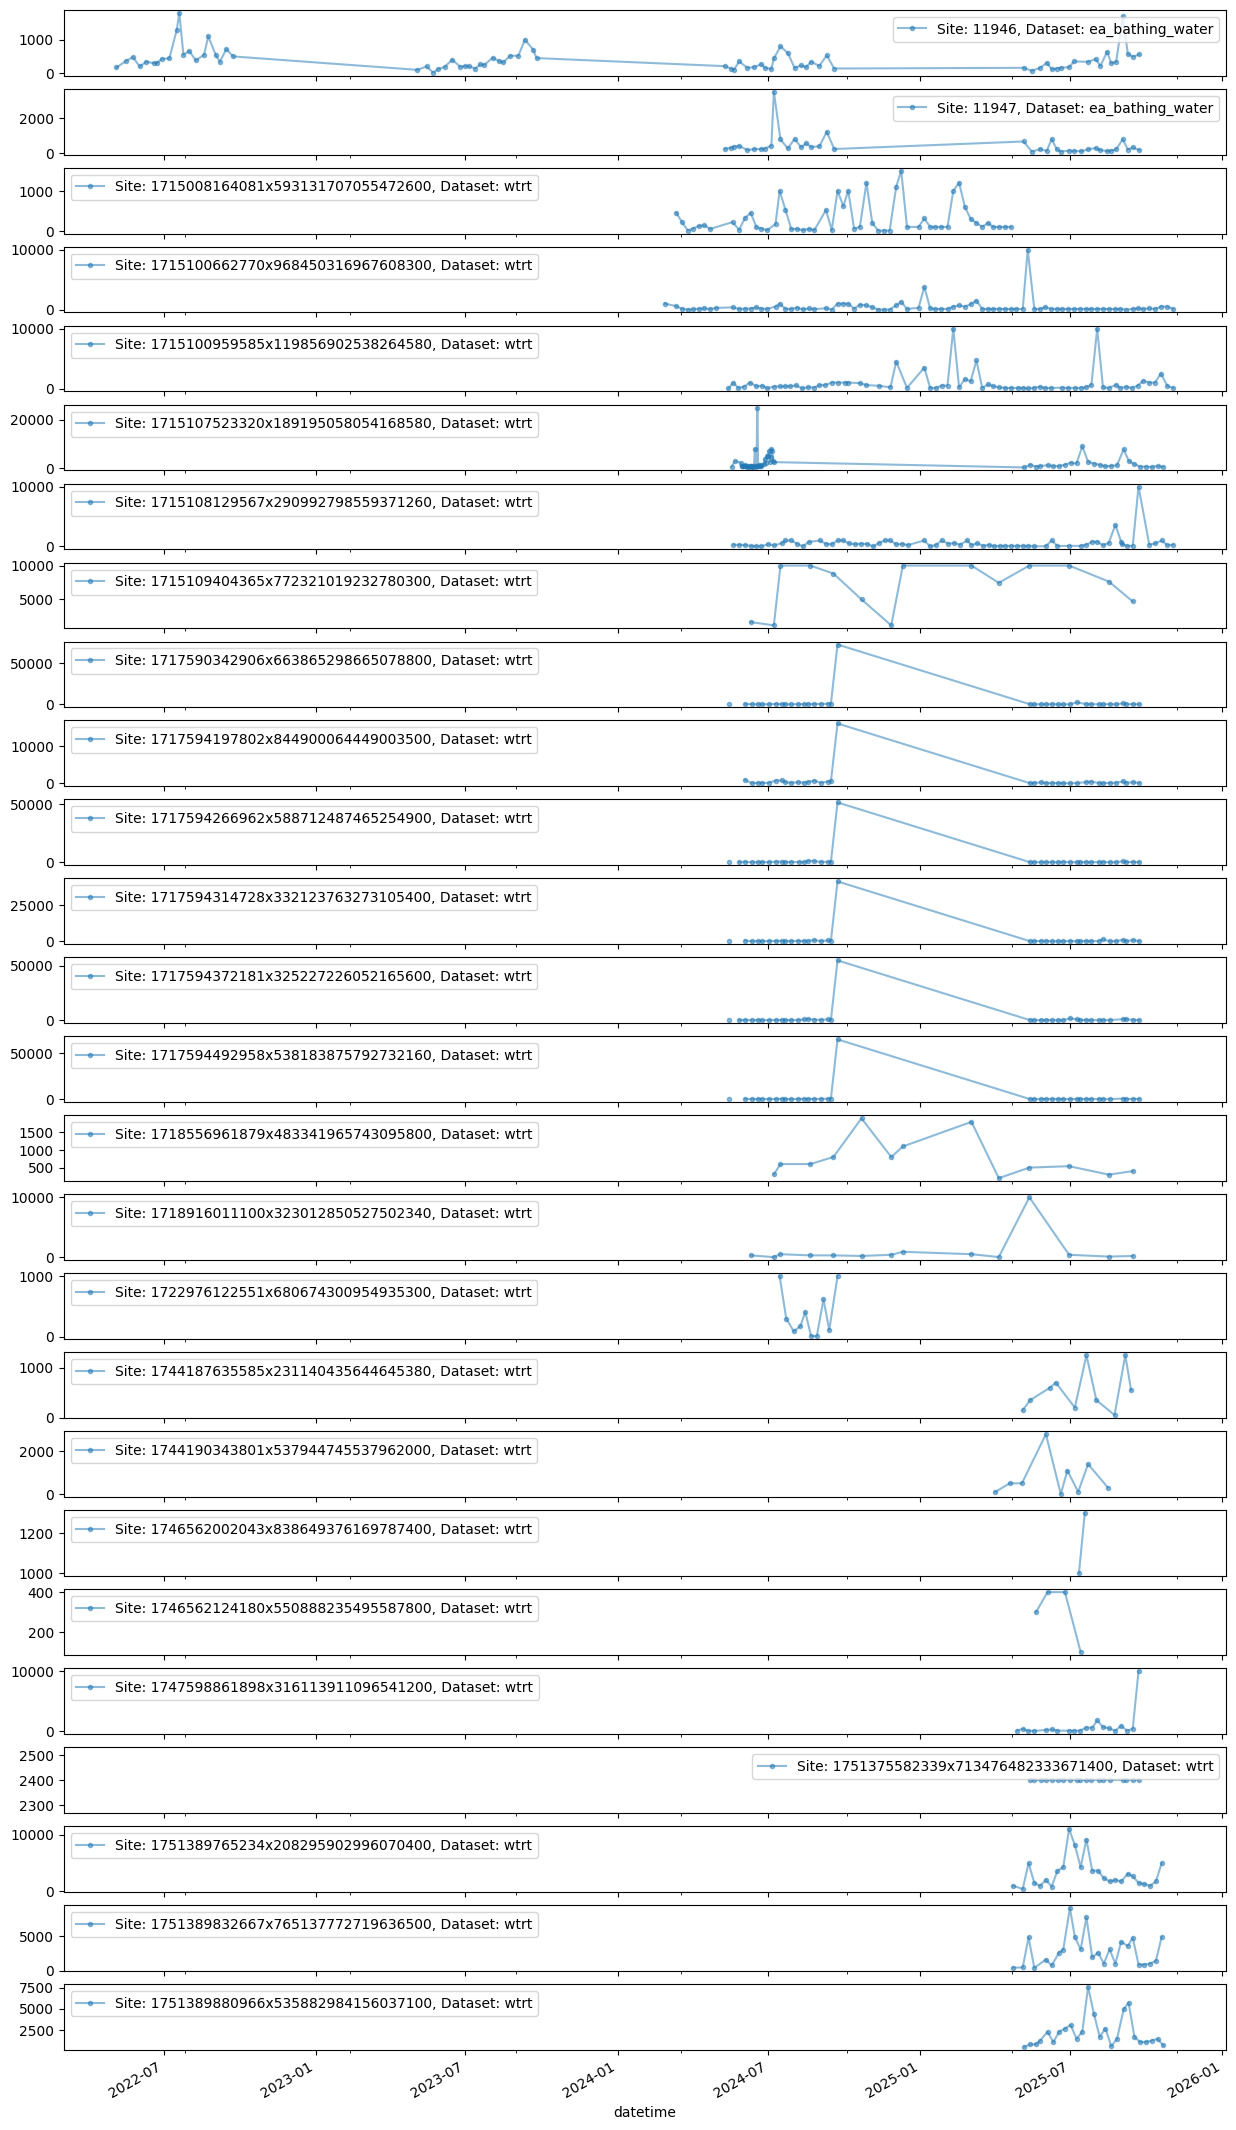

In [6]:
no_dfs = len(ecoli_timeseries_dfs)

fig, ax = plt.subplots(no_dfs, figsize=(15, 30), sharex=True)

#properly align dates, fill missing dates with NaN, deal with multiple measurements in a day
dates_complete = pd.date_range(start='2021-01-01', end='2025-11-01', freq='D')

for i, (df, key) in enumerate(zip(ecoli_timeseries_dfs.values(), ecoli_timeseries_dfs.keys())):
    df['datetime'] = df['datetime'].dt.floor('D') # Keep date only, ignore time of measurement
    df = df.groupby('datetime').first().reset_index() #in case of multiple measurements in a day, take first
    #df = df.set_index('datetime').reindex(dates_complete).reset_index().rename(columns={'index': 'datetime'})
    df.plot(x='datetime', y='escherichia coli count', ax=ax[i], alpha=0.5, label = f'Site: {key[0]}, Dataset: {key[1]}', style='.-')
    ax[i].legend()

Get predictors for a given target site

In [71]:
#CHANGE SITES TO SELECT HERE
max_distance = 0.075 # e.g., within 0.075 degrees (~8 km)
no_keep = 3 #number of nearby sites to keep for each dataset

#CHANGE TO DESIRED TARGET SITE HERE
target_dataset = 'ea_bathing_water' #wtrt or ea_bathing_water
target_name = 'Wolvercote Mill Stream' #e.g. 'Boulters Lock (Laboratory testing)' or 'Wolvercote Mill Stream'

In [72]:
all_datasets = ['ea_bathing_water','edm', 'rainfall', 'fft', 'ea_water_quality', 'ea_lf_sonde', 'ea_wq_sonde', 'wtrt'] #ea_flood_warnings doesn't have timeseries data, freshwater_watch as data is v messy
predictor_datasets = [ds for ds in all_datasets if ds != 'ea_bathing_water'] #don't include bathing water data as predictor #ds != target_dataset and
site_names_determinands = ['ea_water_quality', 'ea_wq_sonde', 'ea_lf_sonde'] #datasets that require determinands
date_datasets = ['edm']

sites_dfs = {}

#extract all site details and convert to GeoDataFrames
for dataset_name in all_datasets:
    df = app.get_sites_for_dataset_as_pandas(dataset_name, display=False)
    df = gpd.GeoDataFrame(df)
    df['geometry.coordinates'] = gpd.points_from_xy(pd.DataFrame(df["geometry.coordinates"].to_list())[0], pd.DataFrame(df["geometry.coordinates"].to_list())[1])
    df.set_geometry('geometry.coordinates', inplace=True)
    sites_dfs[dataset_name] = df

In [73]:
#extract details about target dataset
target_location = sites_dfs[target_dataset][sites_dfs[target_dataset]["properties.name"] == target_name]["geometry.coordinates"]
target_id = sites_dfs[target_dataset][sites_dfs[target_dataset]["properties.name"] == target_name]["properties.id"].values[0]
target_ecoli = ecoli_timeseries_dfs[(target_id, target_dataset)].set_index('datetime')

complete_target_dates = pd.date_range(start=target_ecoli['escherichia coli count'].index.min(), end=target_ecoli['escherichia coli count'].index.max(), freq='D')
df_target = pd.DataFrame(index = complete_target_dates)
df_target = pd.concat([df_target, target_ecoli['escherichia coli count']], axis = 1) #extract e-coli as target variable
df_target['datetime'] = df_target.index
df_target['datetime'] = df_target['datetime'].dt.tz_localize(None) #remove timezone info for merging
df_target = df_target.rename(columns={'escherichia coli count': 'target_ecoli'}).set_index('datetime')

In [74]:
# find sites near target location
nearby_dfs = {}

for dataset_name in predictor_datasets:
    df = sites_dfs[dataset_name]
    df['distance_to_target'] = df['geometry.coordinates'].distance(target_location.values[0])
    nearby_sites = df[df['distance_to_target'] < max_distance].copy()
    nearby_sites_sort = nearby_sites.sort_values(by='distance_to_target')
    nearby_dfs[dataset_name] = nearby_sites_sort[0:no_keep] #keep only no_keep closest sites to reduce amount of data

In [81]:
# extract timeseries data for nearby sites

timeseries_dfs = {}

for dataset_name in predictor_datasets:
    df_sites = nearby_dfs[dataset_name]

    if dataset_name =='wtrt':
        timeseries_dfs[dataset_name] = pd.DataFrame()
        for index, row in df_sites.iterrows():
            if row['properties.name'] == target_name:
                continue
            else:
                try:
                    site_name = row['properties.name']
                    df_site = ecoli_timeseries_dfs[(row['properties.id'], dataset_name)]
                    df_site['datetime'] = pd.to_datetime(df_site['datetime']).dt.floor('D')
                    df_site['datetime'] = df_site['datetime'].dt.tz_localize(None) #remove timezone info for merging
                    df_site = df_site.set_index('datetime')['escherichia coli count'].to_frame() #note this drops the > = < column
                    df_site = df_site.rename(columns={'escherichia coli count': f'{dataset_name}_{site_name}'})
                    timeseries_dfs[dataset_name] = pd.concat([timeseries_dfs[dataset_name], df_site], axis=1)
                except Exception as e:
                    print(f"Error processing site {site_name} in dataset {dataset_name}: {e}")

    elif dataset_name not in site_names_determinands and dataset_name not in date_datasets: #i.e. datasets that do not require determinand IDs or date to extract timeseries
        timeseries_dfs[dataset_name] = pd.DataFrame()
        for index, row in df_sites.iterrows():
            try:
                site_name = row['properties.id']
                df_site = app.get_timeseries_for_dataset_and_site_as_pandas(site_name, dataset_name, display=False)
                df_site['datetime'] = pd.to_datetime(df_site['datetime'])
                df_site = df_site.sort_values('datetime').reset_index(drop=True)
                
                if dataset_name == 'fft':
                    df_site['datetime'] = df_site['datetime'].dt.floor('D') # Get average per day
                    df_site = df_site.groupby('datetime').mean().reset_index()

                df_site = df_site.rename(columns={'value': f'{dataset_name}_{site_name}'})
                df_site = df_site.set_index('datetime')
                timeseries_dfs[dataset_name] = pd.concat([timeseries_dfs[dataset_name], df_site], axis=1)
            except Exception as e:
                print(f"Error processing site {site_name} in dataset {dataset_name}: {e}")

    elif dataset_name in date_datasets: #i.e. datasets that require date to extract timeseries (i.e. edm)
        timeseries_dfs[dataset_name] = pd.DataFrame()
        for index, row in df_sites.iterrows():
            try:
                site_name = row['properties.id']
                date = datetime.date(2021, 1, 1)
                df_site = app.get_timeseries_for_date_dataset_as_pandas(site_name, dataset_name, date, display=False)

                df_site['datetime'] = pd.to_datetime(df_site['datetime'])
                df_site = df_site.sort_values('datetime').reset_index(drop=True)
                df_site = app.process_edm(df_site)
                df_site = df_site.rename(columns={'duration_hours': f'{dataset_name}_{site_name}'})
                df_site['datetime'] = pd.to_datetime(df_site['datetime'])
                df_site = df_site.set_index('datetime')
                timeseries_dfs[dataset_name] = pd.concat([timeseries_dfs[dataset_name], df_site], axis=1)
            except Exception as e:
                print(f"Error processing site {site_name} in dataset {dataset_name}: {e}")

    else: #i.e. datasets that require determinand IDs to extract timeseries
        timeseries_dfs[dataset_name] = pd.DataFrame()
        for index, row in df_sites.iterrows():
            try:
                site_name = row['properties.id']
                if dataset_name == 'ea_lf_sonde':
                    determinands = row['properties.measures']
                    determinands = [determinands[i][0] for i in range(len(determinands))]
                elif dataset_name == 'ea_wq_sonde':
                    determinands = row['properties.measures']
                    determinands = [determinands[i][0] for i in range(len(determinands))]
                elif dataset_name == 'ea_water_quality':
                    determinands = row['properties.determinand_ids']
                else:
                    print(f"Dataset {dataset_name} not recognised for determinand extraction.")
                for determinand in determinands:
                    df_site = app.get_timeseries_for_dataset_site_determinand_as_pandas(site_name, dataset_name, determinand, display=False)

                    df_site['datetime'] = pd.to_datetime(df_site['datetime'])
                    df_site = df_site.sort_values('datetime').reset_index(drop=True)
                    df_site = df_site.rename(columns={'value': f'{dataset_name}_{site_name}_{determinand}'})
                    df_site['datetime'] = df_site['datetime'].dt.floor('D') # Get average per day
                    df_site = df_site.groupby('datetime').mean().reset_index()
                    df_site = df_site.set_index('datetime')
                    timeseries_dfs[dataset_name] = pd.concat([timeseries_dfs[dataset_name], df_site], axis=1)

            except Exception as e:
                print(f"Error processing site {site_name} in dataset {dataset_name}: {e}")
        #df_site = app.get_timeseries_for_dataset_site_determinand_as_pandas("E01612A", "ea_wq_sonde", "turbidity", display=False)
        continue


Error processing site Tumbling Bay Bathing Area, Oxford (Laboratory testing) in dataset wtrt: ('1743499042454x452904883018006500', 'wtrt')


In [82]:
#bring all time series into a common dataframe

df_predictors = pd.DataFrame(index = dates_complete)

for dataset_name, df in timeseries_dfs.items():
    df_predictors = pd.concat([df_predictors, df], axis=1)

if target_dataset == 'ea_bathing_water': #wtrt doesn't have enterococci data
    enterococci_predictor = target_ecoli['intestinal enterococci count'] #extract enterococci as predictor variable to add to other predictors
    df_predictors = pd.concat([df_predictors, enterococci_predictor], axis=1)

In [83]:
df_predictors

,"edm_West Way, Botley (Syphon)",edm_Cassington,"edm_The Willows, North Hinksey Lane",rainfall_39034,rainfall_39008,rainfall_39140,fft_Cassington,ea_water_quality_TH-PGWL0228_0111,ea_water_quality_TH-PGWL0228_0061,ea_water_quality_TH-PGWL0228_0076,...,ea_wq_sonde_E10993A_ammonium,ea_wq_sonde_E10993A_dissolved-oxygen,ea_wq_sonde_E10993A_conductivity,ea_wq_sonde_E10993A_fdom,ea_wq_sonde_E10993A_temperature,ea_wq_sonde_E10993A_ph,ea_wq_sonde_E10993A_turbidity,"wtrt_Folly Bridge, Oxford (Petrifilm)","wtrt_Longbridges, Oxford (Petrifilm)",intestinal enterococci count
2021-01-01,NaN,NaN,NaN,0.505,0.762,0.681,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-02,NaN,NaN,NaN,1.152,1.129,0.617,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-03,NaN,NaN,NaN,0.676,0.647,0.363,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,NaN,NaN,NaN,0.086,0.051,0.035,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,NaN,NaN,NaN,0.166,0.017,0.258,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


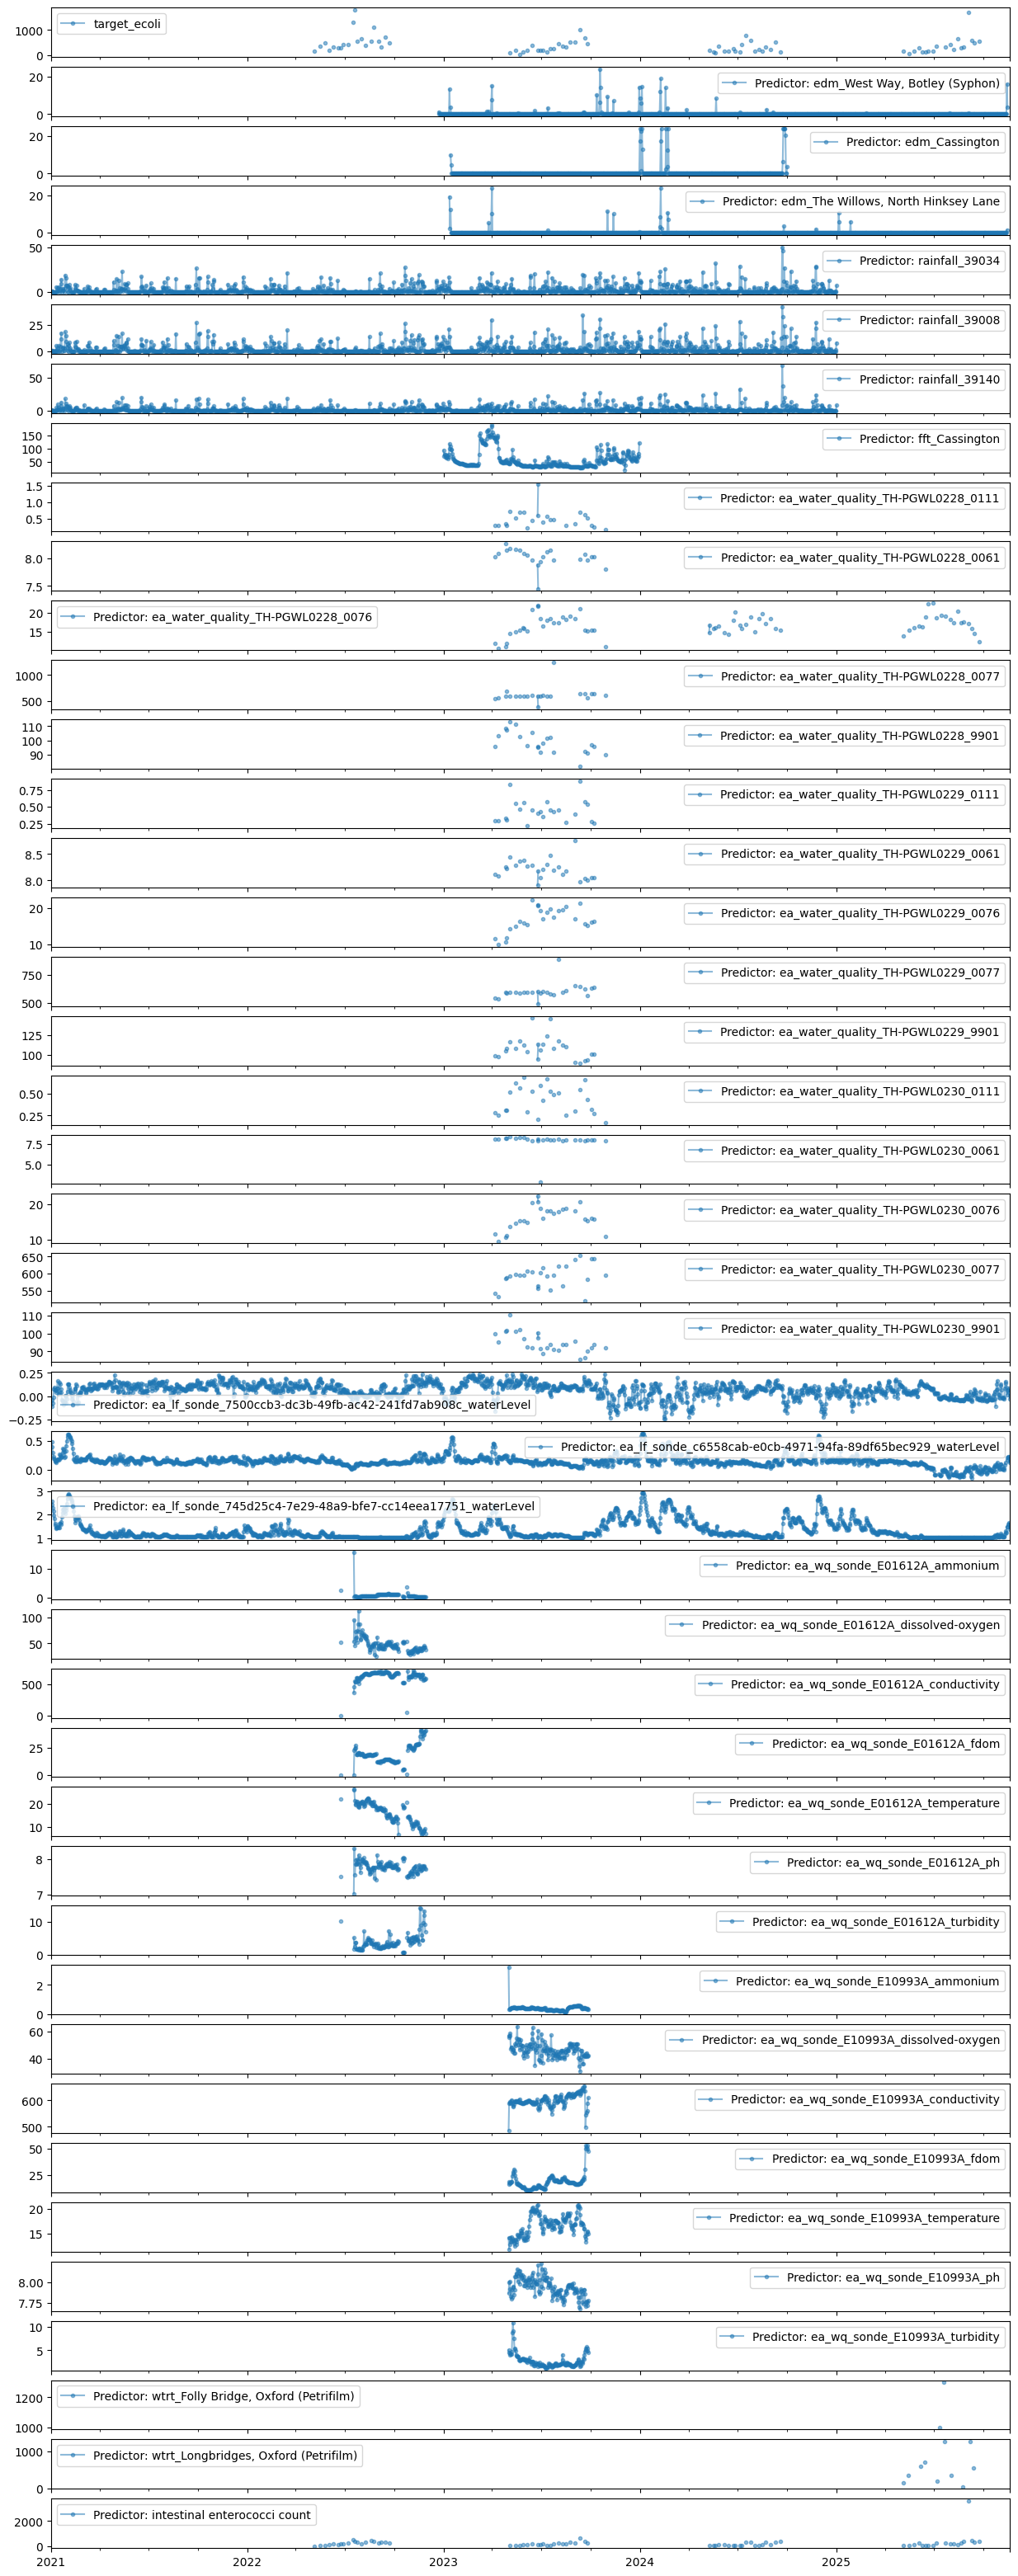

In [84]:
no_predictors = len(df_predictors.columns)
fig, ax = plt.subplots(no_predictors + 1, figsize=(15, 40), sharex = True)

df_target.plot(ax=ax[0], alpha = 0.5, label = 'Target: E. coli count', style='.-')
ax[0].legend()

for i, column in enumerate(df_predictors.columns):
    df_predictors[column].plot(ax=ax[i+1], alpha = 0.5, label = f'Predictor: {column}', style='.-')
    ax[i+1].legend()

To put into an ML algorithm, the datatime for predictors needs to match the target

In [68]:
df_target_predictors = pd.concat([df_target, df_predictors], axis=1)#.dropna()
df_target_predictors

,target_ecoli,edm_Maidenhead,"edm_Marsh Lane Bridge, Taplow",edm_Little Marlow,rainfall_39866,rainfall_39148,rainfall_39009,ea_water_quality_TH-PTHR0173_0111,ea_water_quality_TH-PTHR0173_0116,ea_water_quality_TH-PTHR0173_0117,...,ea_water_quality_TH-RSN1074_0301,ea_water_quality_TH-RSN1074_0348,ea_water_quality_TH-RSN1074_0061,ea_water_quality_TH-RSN1074_0076,ea_water_quality_TH-RSN1074_0077,ea_water_quality_TH-RSN1074_9686,ea_water_quality_TH-RSN1074_9901,ea_water_quality_TH-RSN1074_9924,"wtrt_Jubilee River, Marsh Lane (Laboratory testing)","wtrt_Riversdale, Bourne End (Laboratory testing)"
2021-01-01,NaN,NaN,NaN,NaN,0.945,0.945,0.945,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-02,NaN,NaN,NaN,NaN,0.651,0.650,0.650,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-03,NaN,NaN,NaN,NaN,0.524,0.524,0.523,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,NaN,NaN,NaN,NaN,0.088,0.088,0.088,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,NaN,NaN,NaN,NaN,0.272,0.272,0.272,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Some variables with short time series would need to be removed

In [17]:
df_target_predictors = pd.concat([df_target, df_predictors.drop(columns = 'fft_Cassington')], axis=1).dropna()
df_target_predictors

,escherichia coli count,"edm_West Way, Botley (Syphon)",edm_Cassington,"edm_The Willows, North Hinksey Lane",rainfall_39034,rainfall_39008,rainfall_39140,ea_water_quality_TH-PGWL0228_0111,ea_water_quality_TH-PGWL0228_0061,ea_water_quality_TH-PGWL0228_0076,...,ea_wq_sonde_E01612A_ph,ea_wq_sonde_E01612A_turbidity,ea_wq_sonde_E10993A_ammonium,ea_wq_sonde_E10993A_dissolved-oxygen,ea_wq_sonde_E10993A_conductivity,ea_wq_sonde_E10993A_fdom,ea_wq_sonde_E10993A_temperature,ea_wq_sonde_E10993A_ph,ea_wq_sonde_E10993A_turbidity,intestinal enterococci count


Predictors can be lagged to predict forward in time

In this case however, I'm not sure how doing a prediction would work. The target (e-coli at Wolvercote) is measured irregularly and not very often. 

The aim of the project was to be able to predict e-coli e.g. 2 days ahead, but ecoli isn't measured at daily frequency which makes this difficult

If enough other data exists at daily frequency, we could train and test the model with the available e-coli data. The same model could then be used to predict e-coli on days when it isn't measured, using the predictors that are measured.

In [18]:
df_target = df_target_predictors['escherichia coli count']

df_predictors = df_target_predictors.shift(2)

In [19]:
df_target

Series([], Freq: D, Name: escherichia coli count, dtype: float64)

In [20]:
df_predictors

,escherichia coli count,"edm_West Way, Botley (Syphon)",edm_Cassington,"edm_The Willows, North Hinksey Lane",rainfall_39034,rainfall_39008,rainfall_39140,ea_water_quality_TH-PGWL0228_0111,ea_water_quality_TH-PGWL0228_0061,ea_water_quality_TH-PGWL0228_0076,...,ea_wq_sonde_E01612A_ph,ea_wq_sonde_E01612A_turbidity,ea_wq_sonde_E10993A_ammonium,ea_wq_sonde_E10993A_dissolved-oxygen,ea_wq_sonde_E10993A_conductivity,ea_wq_sonde_E10993A_fdom,ea_wq_sonde_E10993A_temperature,ea_wq_sonde_E10993A_ph,ea_wq_sonde_E10993A_turbidity,intestinal enterococci count
